# Supervisor Report — Multimodal Fraud Detection

## Research narrative

**Comparison 1 — Tabular vs tabular** (same MM dataset, fair)
LR and XGBoost on transaction features only — baseline capability with no images.

**Comparison 2 — Image vs image** (same MM dataset, fair)
ResNet-18 and EfficientNet-B0 on document images only — and their key failure case.

**Comparison 3 — Multimodal vs each baseline** (same MM dataset, fair)
Late-fusion model vs image-only and tabular-only — the main thesis result.

**Context — Full PaySim tabular** (different scale, not directly comparable)
LR and XGBoost trained on ~6.3M PaySim rows. Reported as a reference ceiling,
not a direct competitor, because the dataset is ~900× larger.

> **Cost function:** FN × $50,000 + FP × $500


## 0. Setup

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LogNorm
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, auc as sk_auc,
    average_precision_score,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

PROJECT_ROOT = Path().resolve().parent
R_FULL  = PROJECT_ROOT / "results"
R_NB    = PROJECT_ROOT / "notebook" / "results"
REPORT_DIR = R_NB
REPORT_DIR.mkdir(parents=True, exist_ok=True)

FN_COST, FP_COST = 50_000, 500

def fmt_cost(v):
    if pd.isna(v): return "N/A"
    return f"${v/1_000_000:.2f}M" if v >= 1_000_000 else f"${v/1_000:.0f}K"

COLOURS = {
    "LR (MM-tabular)":           "#4C72B0",
    "XGB (MM-tabular)":          "#55A868",
    "ResNet-18 (image-only)":    "#DD8452",
    "EfficientNet (image-only)": "#C44E52",
    "Multimodal ResNet-18":      "#9467BD",
    "Multimodal EfficientNet":   "#E377C2",
    "LR (PaySim)":               "#AEC7E8",
    "XGB (PaySim)":              "#98DF8A",
}
COMBO_COLOURS = {"tab0_img0":"#4C72B0","tab1_img1":"#C44E52",
                 "tab1_img0":"#DD8452","tab0_img1":"#55A868"}
print("Setup done.")


Setup done.


## 1. Load all saved results

In [ ]:
def load_json(p):
    try: return json.loads(Path(p).read_text())
    except: return {}

def load_csv(p):
    try: return pd.read_csv(p)
    except: return pd.DataFrame()

def load_cm(p):
    try:
        df = pd.read_csv(p, index_col=0)
        return df.values.astype(int)
    except: return None

def first_cm(*paths):
    for p in paths:
        cm = load_cm(p)
        if cm is not None: return cm
    return None

def load_experiment(folder, prefix, label, model_family, dataset, features, imbalance):
    folder = Path(folder)
    rec = {"label": label, "model_family": model_family, "dataset": dataset,
           "features": features, "imbalance": imbalance}

    tm = load_json(folder / f"{prefix}_test_metrics.json")
    if not tm:
        ms = load_csv(folder / f"{prefix}_metrics_summary.csv")
        if not ms.empty and len(ms) > 1:
            tm = ms.iloc[1].to_dict()
    for k in ["precision", "recall", "f1", "roc_auc", "pr_auc", "accuracy"]:
        rec[f"default_{k}"] = float(tm.get(k, np.nan))

    tt = load_json(folder / f"{prefix}_tuned_test_metrics.json")
    if not tt:
        tc = load_csv(folder / f"{prefix}_tuned_metrics.csv")
        if not tc.empty:
            tt = tc.iloc[0].to_dict()
    rec["tuned_threshold"] = float(tt.get("threshold", np.nan))
    for k in ["precision", "recall", "f1"]:
        rec[f"tuned_{k}"] = float(tt.get(k, np.nan))

    rec["cm_tuned"] = first_cm(
        folder / f"{prefix}_tuned_test_confusion_matrix.csv",
        folder / f"{prefix}_tuned_cm.csv",
    )

    cm_from_file = first_cm(folder / f"{prefix}_test_confusion_matrix.csv")
    if cm_from_file is not None:
        rec["cm_default"] = cm_from_file
    else:
        pred_tmp = load_csv(folder / "test_predictions.csv")
        if (not pred_tmp.empty
                and "y_true" in pred_tmp.columns
                and "y_prob" in pred_tmp.columns):
            from sklearn.metrics import confusion_matrix as skm_cm
            y_pred_05 = (pred_tmp["y_prob"].values >= 0.5).astype(int)
            rec["cm_default"] = skm_cm(
                pred_tmp["y_true"].values, y_pred_05, labels=[0, 1])
        else:
            rec["cm_default"] = rec["cm_tuned"]

    cost_df = load_csv(folder / f"{prefix}_cost_results.csv")
    if not cost_df.empty and "expected_cost" in cost_df.columns:
        rec["expected_cost"] = int(cost_df.iloc[0]["expected_cost"])
    elif rec["cm_tuned"] is not None:
        tn, fp, fn, tp = rec["cm_tuned"].ravel()
        rec["expected_cost"] = int(fn * FN_COST + fp * FP_COST)
    else:
        rec["expected_cost"] = np.nan

    rec["pred_df"]     = load_csv(folder / "test_predictions.csv")
    rec["subgroup_df"] = load_csv(folder / "subgroup_combo_type.csv")
    return rec

print("Loaders ready.")


In [3]:
specs = [
    # Full PaySim — reference
    (R_FULL/"tabular_full_baseline_none",         "none",         "LR / none",          "LR (PaySim)",  "PaySim","Raw",       "None"),
    (R_FULL/"tabular_full_baseline_class_weight", "class_weight", "LR / class-weight",  "LR (PaySim)",  "PaySim","Raw",       "Class weight"),
    (R_FULL/"tabular_full_baseline_smote",        "smote",        "LR / SMOTE",         "LR (PaySim)",  "PaySim","Raw",       "SMOTE"),
    (R_FULL/"xgb_nofe_none",    "nofe_none",    "XGB / raw / none",  "XGB (PaySim)","PaySim","Raw",       "None"),
    (R_FULL/"xgb_nofe_weighted","nofe_weighted","XGB / raw / weight", "XGB (PaySim)","PaySim","Raw",       "pos-weight"),
    (R_FULL/"xgb_nofe_smote",   "nofe_smote",   "XGB / raw / SMOTE",  "XGB (PaySim)","PaySim","Raw",       "SMOTE"),
    (R_FULL/"xgb_fe_none",      "fe_none",      "XGB / FE / none",   "XGB (PaySim)","PaySim","Engineered","None"),
    (R_FULL/"xgb_fe_weighted",  "fe_weighted",  "XGB / FE / weight", "XGB (PaySim)","PaySim","Engineered","pos-weight"),
    (R_FULL/"xgb_fe_smote",     "fe_smote",     "XGB / FE / SMOTE",  "XGB (PaySim)","PaySim","Engineered","SMOTE"),
    # Image-only
    (R_NB/"mm_image_resnet18"/"A_weighted",        "normal",  "ResNet-18 / normal",    "ResNet-18 (image-only)",    "MM","Image","pos-weight"),
    (R_NB/"mm_image_resnet18"/"B_sampler",         "sampler", "ResNet-18 / sampler",   "ResNet-18 (image-only)",    "MM","Image","pos-weight+sampler"),
    (R_NB/"mm_image_efficientnet_b0"/"A_weighted", "normal",  "EfficientNet / normal", "EfficientNet (image-only)", "MM","Image","pos-weight"),
    (R_NB/"mm_image_efficientnet_b0"/"B_sampler",  "sampler", "EfficientNet / sampler","EfficientNet (image-only)", "MM","Image","pos-weight+sampler"),
    # MM tabular
    (R_NB/"mm_tabular_logreg"/"A_none",   "A_none",   "LR-MM / raw / none",    "LR (MM-tabular)","MM","Raw",       "None"),
    (R_NB/"mm_tabular_logreg"/"A_weight", "A_weight", "LR-MM / raw / weight",  "LR (MM-tabular)","MM","Raw",       "Class weight"),
    (R_NB/"mm_tabular_logreg"/"A_smote",  "A_smote",  "LR-MM / raw / SMOTE",   "LR (MM-tabular)","MM","Raw",       "SMOTE"),
    (R_NB/"mm_tabular_logreg"/"B_none",   "B_none",   "LR-MM / FE / none",     "LR (MM-tabular)","MM","Engineered","None"),
    (R_NB/"mm_tabular_logreg"/"B_weight", "B_weight", "LR-MM / FE / weight",   "LR (MM-tabular)","MM","Engineered","Class weight"),
    (R_NB/"mm_tabular_logreg"/"B_smote",  "B_smote",  "LR-MM / FE / SMOTE",   "LR (MM-tabular)","MM","Engineered","SMOTE"),
    (R_NB/"mm_tabular_xgboost"/"A_none",  "A_none",   "XGB-MM / raw / none",   "XGB (MM-tabular)","MM","Raw",       "None"),
    (R_NB/"mm_tabular_xgboost"/"A_weight","A_weight", "XGB-MM / raw / weight", "XGB (MM-tabular)","MM","Raw",       "pos-weight"),
    (R_NB/"mm_tabular_xgboost"/"A_smote", "A_smote",  "XGB-MM / raw / SMOTE",  "XGB (MM-tabular)","MM","Raw",       "SMOTE"),
    (R_NB/"mm_tabular_xgboost"/"B_none",  "B_none",   "XGB-MM / FE / none",    "XGB (MM-tabular)","MM","Engineered","None"),
    (R_NB/"mm_tabular_xgboost"/"B_weight","B_weight", "XGB-MM / FE / weight",  "XGB (MM-tabular)","MM","Engineered","pos-weight"),
    (R_NB/"mm_tabular_xgboost"/"B_smote", "B_smote",  "XGB-MM / FE / SMOTE",  "XGB (MM-tabular)","MM","Engineered","SMOTE"),
    # Multimodal fusion
    (R_NB/"mm_deep_resnet18"/"A_raw_normal",        "A_raw_normal",  "Fusion-ResNet / raw / normal",  "Multimodal ResNet-18","MM","Raw",       "Normal"),
    (R_NB/"mm_deep_resnet18"/"B_raw_sampler",       "B_raw_sampler", "Fusion-ResNet / raw / sampler", "Multimodal ResNet-18","MM","Raw",       "Sampler"),
    (R_NB/"mm_deep_resnet18"/"C_fe_normal",         "C_fe_normal",   "Fusion-ResNet / FE / normal",   "Multimodal ResNet-18","MM","Engineered","Normal"),
    (R_NB/"mm_deep_resnet18"/"D_fe_sampler",        "D_fe_sampler",  "Fusion-ResNet / FE / sampler",  "Multimodal ResNet-18","MM","Engineered","Sampler"),
    (R_NB/"mm_deep_efficientnet_b0"/"A_raw_normal", "A_raw_normal",  "Fusion-EffNet / raw / normal",  "Multimodal EfficientNet","MM","Raw",       "Normal"),
    (R_NB/"mm_deep_efficientnet_b0"/"B_raw_sampler","B_raw_sampler", "Fusion-EffNet / raw / sampler", "Multimodal EfficientNet","MM","Raw",       "Sampler"),
    (R_NB/"mm_deep_efficientnet_b0"/"C_fe_normal",  "C_fe_normal",   "Fusion-EffNet / FE / normal",   "Multimodal EfficientNet","MM","Engineered","Normal"),
    (R_NB/"mm_deep_efficientnet_b0"/"D_fe_sampler", "D_fe_sampler",  "Fusion-EffNet / FE / sampler",  "Multimodal EfficientNet","MM","Engineered","Sampler"),
]

experiments  = [load_experiment(*s) for s in specs]
mm_exps      = [e for e in experiments if e["dataset"]=="MM"]
paysim_exps  = [e for e in experiments if e["dataset"]=="PaySim"]

cols = ["label","model_family","dataset","features","imbalance",
        "default_precision","default_recall","default_f1","default_roc_auc","default_pr_auc",
        "tuned_threshold","tuned_precision","tuned_recall","tuned_f1","expected_cost"]

def to_df(exp_list):
    df = pd.DataFrame([{c: e.get(c) for c in cols} for e in exp_list])
    df = df.dropna(subset=["tuned_f1"]).sort_values("expected_cost").reset_index(drop=True)
    df["cost_fmt"] = df["expected_cost"].apply(fmt_cost)
    return df

master_mm     = to_df(mm_exps)
master_paysim = to_df(paysim_exps)

def best_of(df, families):
    return (df[df["model_family"].isin(families)]
              .sort_values("expected_cost")
              .drop_duplicates("model_family")
              .reset_index(drop=True))

loaded = sum(1 for e in experiments if not np.isnan(e.get("tuned_f1",np.nan)))
print(f"Loaded {loaded}/{len(experiments)} experiments")


Loaded 33/33 experiments


---
## 2. Dataset context — why PaySim and MM results cannot be directly compared


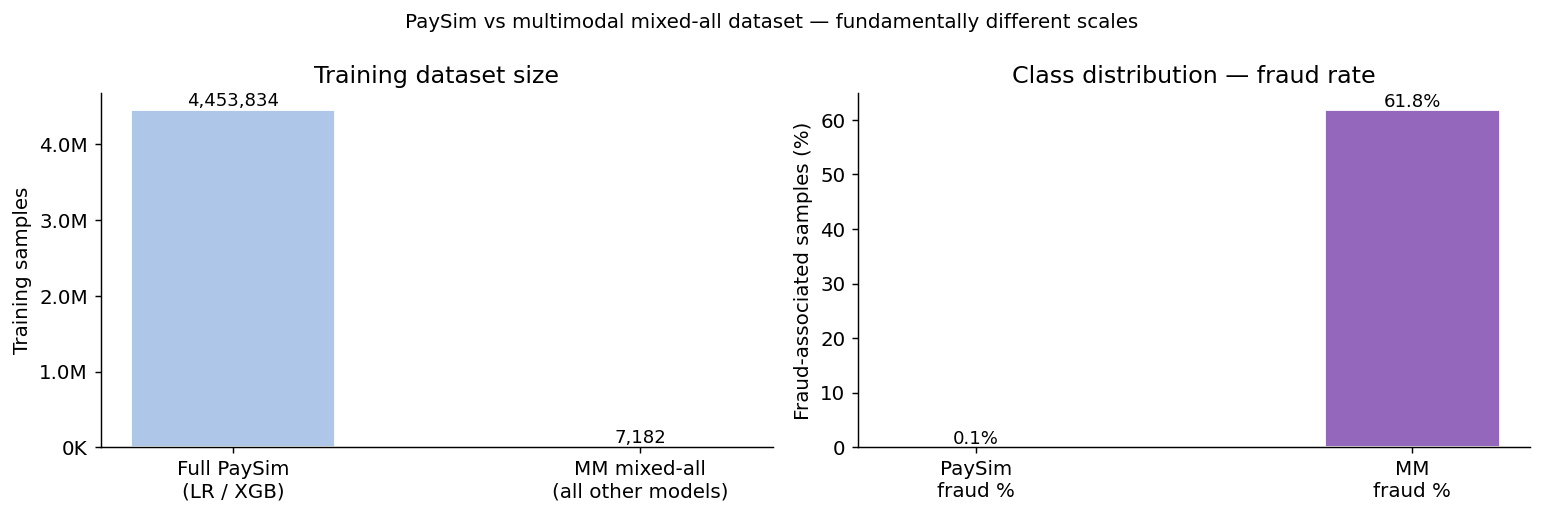

PaySim is ~620× larger than the MM dataset — results are not on equal footing.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training set sizes
datasets  = ["Full PaySim\n(LR / XGB)", "MM mixed-all\n(all other models)"]
sizes     = [4_453_834, 7_182]   # approximate — update if you know exact counts
axes[0].bar(datasets, sizes, color=["#AEC7E8","#9467BD"], edgecolor="white", width=0.5)
axes[0].set_ylabel("Training samples")
axes[0].set_title("Training dataset size")
for i,(d,s) in enumerate(zip(datasets,sizes)):
    axes[0].text(i, s+50_000, f"{s:,}", ha="center", fontsize=10)
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x,_: f"{x/1_000_000:.1f}M" if x>=1e6 else f"{x/1_000:.0f}K"))
axes[0].spines[["top","right"]].set_visible(False)

# Class distributions
labels_cd  = ["PaySim\nfraud %", "MM\nfraud %"]
fraud_pcts = [0.13, 61.8]   # approximate
axes[1].bar(labels_cd, fraud_pcts, color=["#AEC7E8","#9467BD"], edgecolor="white", width=0.4)
axes[1].set_ylabel("Fraud-associated samples (%)")
axes[1].set_title("Class distribution — fraud rate")
for i,v in enumerate(fraud_pcts):
    axes[1].text(i, v+0.5, f"{v:.1f}%", ha="center", fontsize=10)
axes[1].spines[["top","right"]].set_visible(False)

fig.suptitle("PaySim vs multimodal mixed-all dataset — fundamentally different scales",
             fontsize=11)
fig.tight_layout()
fig.savefig(REPORT_DIR/"dataset_context.png", dpi=150, bbox_inches="tight")
plt.show()
print("PaySim is ~620× larger than the MM dataset — results are not on equal footing.")


---
## 3. Comparison 1 — Tabular vs tabular (same MM dataset, fair)

LR and XGBoost trained on transaction features only.
Tests what tabular fraud patterns alone can achieve on this small dataset.


In [5]:
tab_families = ["LR (MM-tabular)","XGB (MM-tabular)"]
tab_df = master_mm[master_mm["model_family"].isin(tab_families)].copy()
best_tab = best_of(master_mm, tab_families)
display(best_tab[["model_family","label","features","imbalance",
                   "tuned_f1","tuned_recall","tuned_precision","cost_fmt"]])


,model_family,label,features,imbalance,tuned_f1,tuned_recall,tuned_precision,cost_fmt
0,XGB (MM-tabular),XGB-MM / FE / SMOTE,Engineered,SMOTE,0.768909,1.0,0.624576,$278K
1,LR (MM-tabular),LR-MM / raw / none,Raw,None,0.768909,1.0,0.624576,$328K


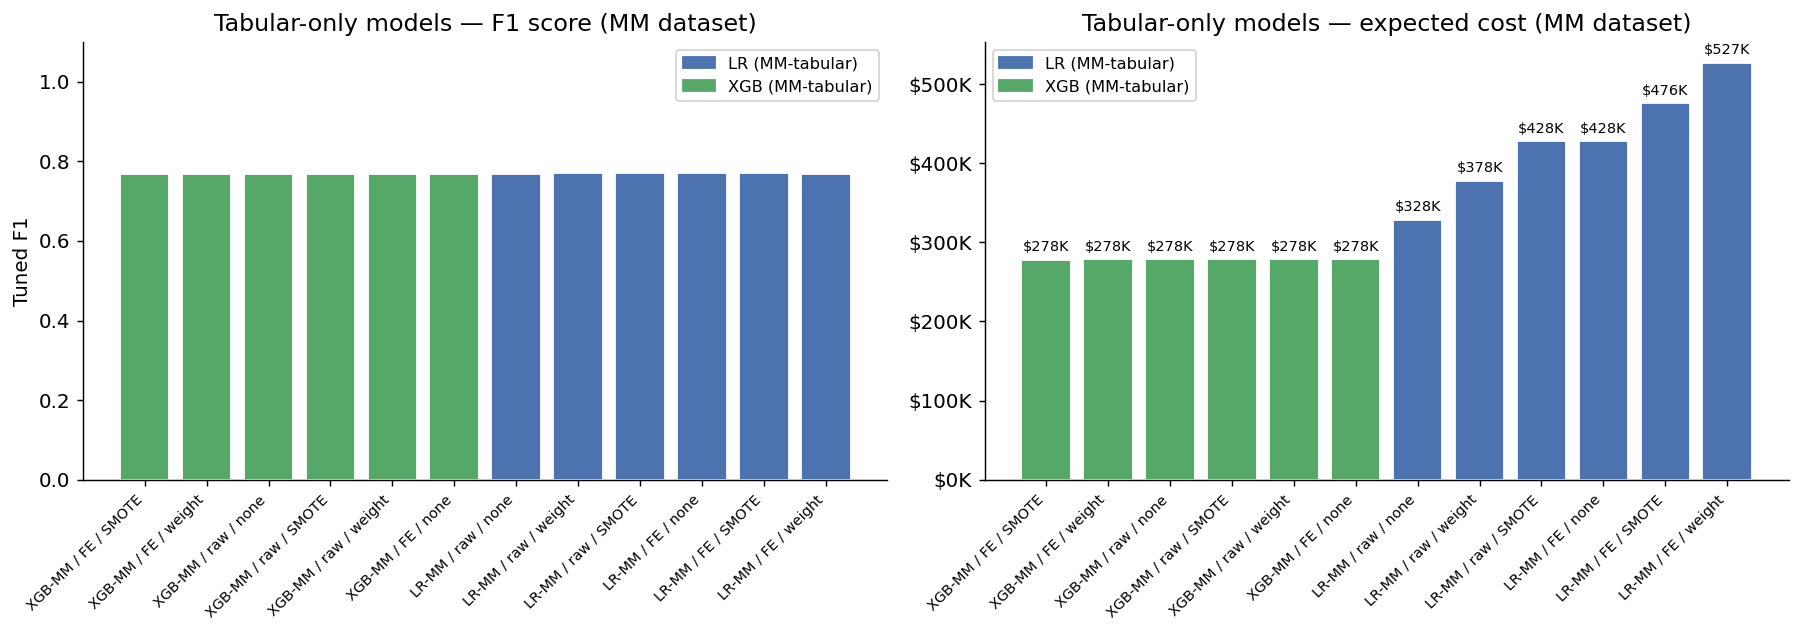

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: F1 grouped bars — LR vs XGB, raw vs FE
x = np.arange(len(tab_df)); w = 0.4
clrs_tab = [COLOURS.get(f,"#888") for f in tab_df["model_family"]]
axes[0].bar(x, tab_df["tuned_f1"], color=clrs_tab, edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels([l[:22] for l in tab_df["label"]], rotation=45, ha="right", fontsize=8)
axes[0].set_ylim(0, 1.1); axes[0].set_ylabel("Tuned F1")
axes[0].set_title("Tabular-only models — F1 score (MM dataset)")
handles_tab = [mpatches.Patch(color=COLOURS[f], label=f) for f in tab_families if f in COLOURS]
axes[0].legend(handles=handles_tab, fontsize=9)
axes[0].spines[["top","right"]].set_visible(False)

# Right: expected cost
cost_tab = tab_df.sort_values("expected_cost")
clrs_tab2 = [COLOURS.get(f,"#888") for f in cost_tab["model_family"]]
bars = axes[1].bar(range(len(cost_tab)), cost_tab["expected_cost"],
                   color=clrs_tab2, edgecolor="white")
axes[1].set_xticks(range(len(cost_tab)))
axes[1].set_xticklabels([l[:22] for l in cost_tab["label"]], rotation=45, ha="right", fontsize=8)
axes[1].bar_label(bars, labels=[fmt_cost(v) for v in cost_tab["expected_cost"]], padding=3, fontsize=8)
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x,_: fmt_cost(x)))
axes[1].set_title("Tabular-only models — expected cost (MM dataset)")
axes[1].legend(handles=handles_tab, fontsize=9)
axes[1].spines[["top","right"]].set_visible(False)

fig.tight_layout()
fig.savefig(REPORT_DIR/"tabular_vs_tabular.png", dpi=150, bbox_inches="tight")
plt.show()


In [7]:
# Feature engineering impact — tabular
print("Feature engineering impact on MM tabular models:")
for fam in tab_families:
    df_f = master_mm[master_mm["model_family"]==fam]
    raw = df_f[df_f["features"]=="Raw"]["expected_cost"].min()
    fe  = df_f[df_f["features"]=="Engineered"]["expected_cost"].min()
    if not (np.isnan(raw) or np.isnan(fe)):
        print(f"  {fam:<25}  Raw: {fmt_cost(raw)}  FE: {fmt_cost(fe)}  gain: {(raw-fe)/max(raw,1)*100:+.1f}%")


Feature engineering impact on MM tabular models:
  LR (MM-tabular)            Raw: $328K  FE: $428K  gain: -30.3%
  XGB (MM-tabular)           Raw: $278K  FE: $278K  gain: +0.2%


---
## 4. Comparison 2 — Image vs image (same MM dataset, fair)

ResNet-18 and EfficientNet-B0 on document images only.
Key question: can the image branch detect fraud without transaction data?
The tab1_img0 group tests this directly.


In [8]:
img_families = ["ResNet-18 (image-only)","EfficientNet (image-only)"]
img_df   = master_mm[master_mm["model_family"].isin(img_families)].copy()
best_img = best_of(master_mm, img_families)
display(best_img[["model_family","label","imbalance","tuned_f1","tuned_recall","cost_fmt"]])


,model_family,label,imbalance,tuned_f1,tuned_recall,cost_fmt
0,EfficientNet (image-only),EfficientNet / sampler,pos-weight+sampler,0.768909,1.0,$278K
1,ResNet-18 (image-only),ResNet-18 / sampler,pos-weight+sampler,0.768588,1.0,$278K


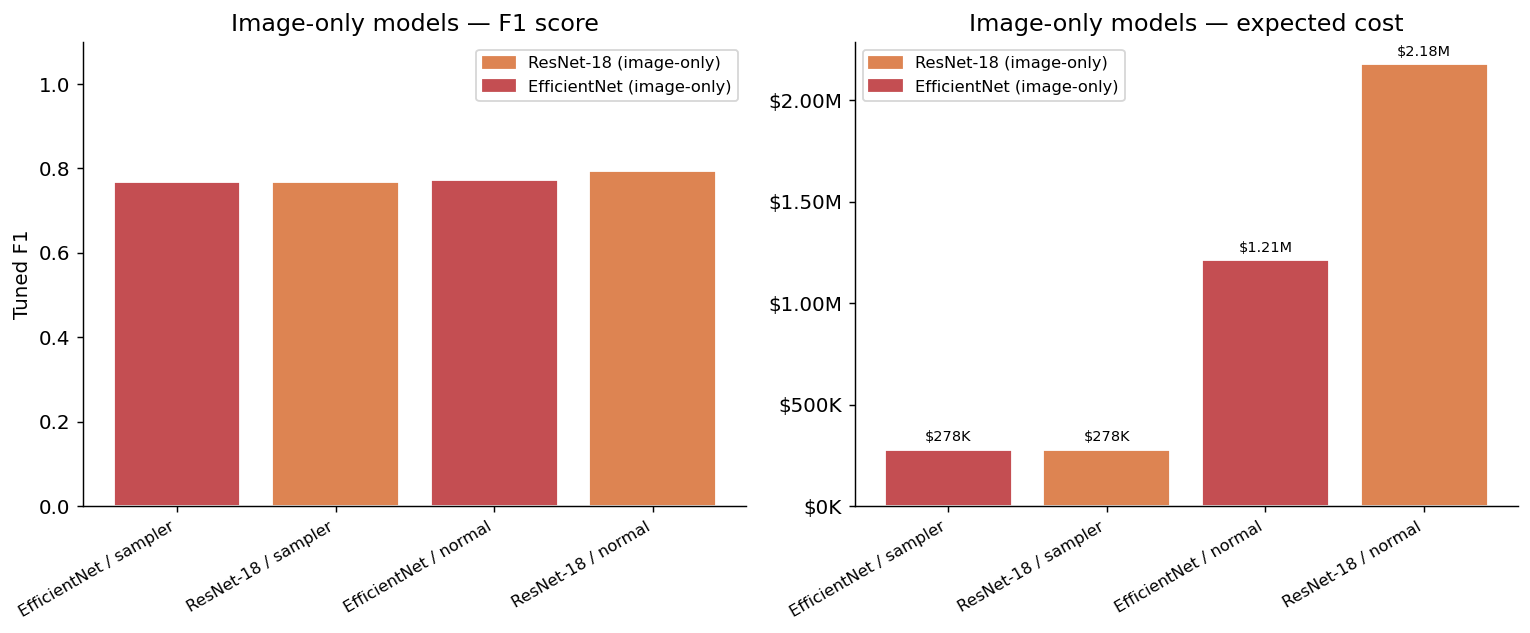

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

clrs_img = [COLOURS.get(f,"#888") for f in img_df["model_family"]]
x = np.arange(len(img_df))

axes[0].bar(x, img_df["tuned_f1"], color=clrs_img, edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels([l[:22] for l in img_df["label"]], rotation=30, ha="right", fontsize=9)
axes[0].set_ylim(0, 1.1); axes[0].set_ylabel("Tuned F1")
axes[0].set_title("Image-only models — F1 score")
handles_img = [mpatches.Patch(color=COLOURS[f],label=f) for f in img_families if f in COLOURS]
axes[0].legend(handles=handles_img, fontsize=9)
axes[0].spines[["top","right"]].set_visible(False)

bars2 = axes[1].bar(range(len(img_df)), img_df["expected_cost"], color=clrs_img, edgecolor="white")
axes[1].set_xticks(range(len(img_df)))
axes[1].set_xticklabels([l[:22] for l in img_df["label"]], rotation=30, ha="right", fontsize=9)
axes[1].bar_label(bars2, labels=[fmt_cost(v) for v in img_df["expected_cost"]], padding=3, fontsize=8)
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x,_: fmt_cost(x)))
axes[1].set_title("Image-only models — expected cost")
axes[1].legend(handles=handles_img, fontsize=9)
axes[1].spines[["top","right"]].set_visible(False)

fig.tight_layout()
fig.savefig(REPORT_DIR/"image_vs_image.png", dpi=150, bbox_inches="tight")
plt.show()


### Image-only limitation — tab1_img0 subgroup

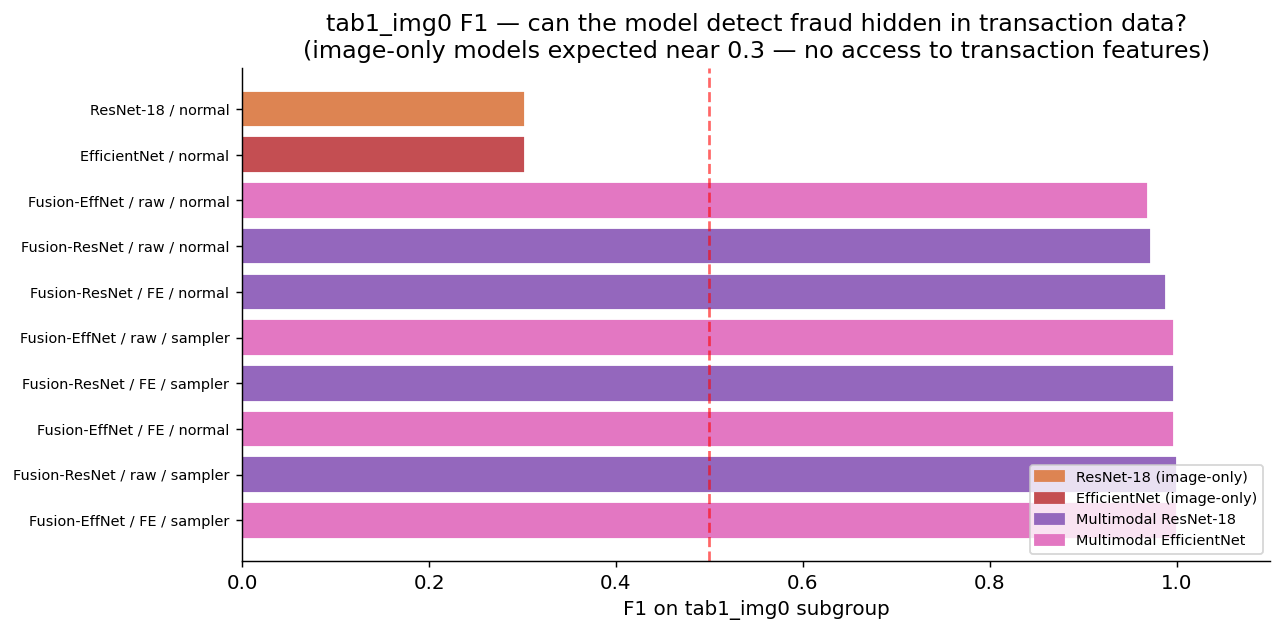

In [10]:
sg_rows = []
for exp in mm_exps:
    sg = exp.get("subgroup_df", pd.DataFrame())
    if sg.empty or "combo_type" not in sg.columns: continue
    for _, r in sg.iterrows():
        sg_rows.append({"label":exp["label"],"family":exp["model_family"],
                        "combo_type":r["combo_type"],"f1":float(r.get("f1",np.nan))})

if sg_rows:
    sg_df  = pd.DataFrame(sg_rows)
    tab1   = sg_df[sg_df["combo_type"]=="tab1_img0"].sort_values("f1",ascending=False)

    # Show image-only tab1_img0 specifically
    tab1_img_only = tab1[tab1["family"].isin(img_families)]
    tab1_mm_tab   = tab1[tab1["family"].isin(tab_families)]
    tab1_fusion   = tab1[tab1["family"].str.startswith("Multimodal")]

    fig, ax = plt.subplots(figsize=(10,5))
    clrs_sg = [COLOURS.get(f,"#888") for f in tab1["family"]]
    ax.barh(range(len(tab1)), tab1["f1"], color=clrs_sg, edgecolor="white")
    ax.set_yticks(range(len(tab1)))
    ax.set_yticklabels([l[:32] for l in tab1["label"]], fontsize=8)
    ax.axvline(0.5, color="red", linestyle="--", alpha=0.6, label="F1=0.5 baseline")
    ax.set_xlabel("F1 on tab1_img0 subgroup")
    ax.set_xlim(0, 1.1)
    ax.set_title("tab1_img0 F1 — can the model detect fraud hidden in transaction data?\n"
                 "(image-only models expected near 0.3 — no access to transaction features)")
    ax.legend(fontsize=9)
    # Colour legend
    handles_all = [mpatches.Patch(color=v,label=k) for k,v in COLOURS.items()
                   if k in tab1["family"].values]
    ax.legend(handles=handles_all, fontsize=8, loc="lower right")
    ax.spines[["top","right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(REPORT_DIR/"tab1_img0_all_models.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No subgroup data yet — run multimodal notebooks first.")


---
## 5. Comparison 3 — Multimodal vs baselines (same MM dataset, main result)

All three model types trained on identical data.
Primary finding: multimodal fusion outperforms both image-only and tabular-only
on the MM dataset, especially on the tab1_img0 subgroup.


In [11]:
all_mm_families = list(COLOURS.keys())[:6]   # MM families only
best_all_mm = best_of(master_mm, all_mm_families)
display(best_all_mm[["model_family","label","features","tuned_f1",
                      "tuned_recall","tuned_precision","cost_fmt"]])


,model_family,label,features,tuned_f1,tuned_recall,tuned_precision,cost_fmt
0,Multimodal ResNet-18,Fusion-ResNet / FE / sampler,Engineered,0.913802,0.996739,0.843606,$78K
1,Multimodal EfficientNet,Fusion-EffNet / FE / sampler,Engineered,0.903733,1.000000,0.824373,$144K
2,EfficientNet (image-only),EfficientNet / sampler,Image,0.768909,1.000000,0.624576,$278K
3,XGB (MM-tabular),XGB-MM / FE / SMOTE,Engineered,0.768909,1.000000,0.624576,$278K
4,ResNet-18 (image-only),ResNet-18 / sampler,Image,0.768588,1.000000,0.624152,$278K
5,LR (MM-tabular),LR-MM / raw / none,Raw,0.768909,1.000000,0.624576,$328K


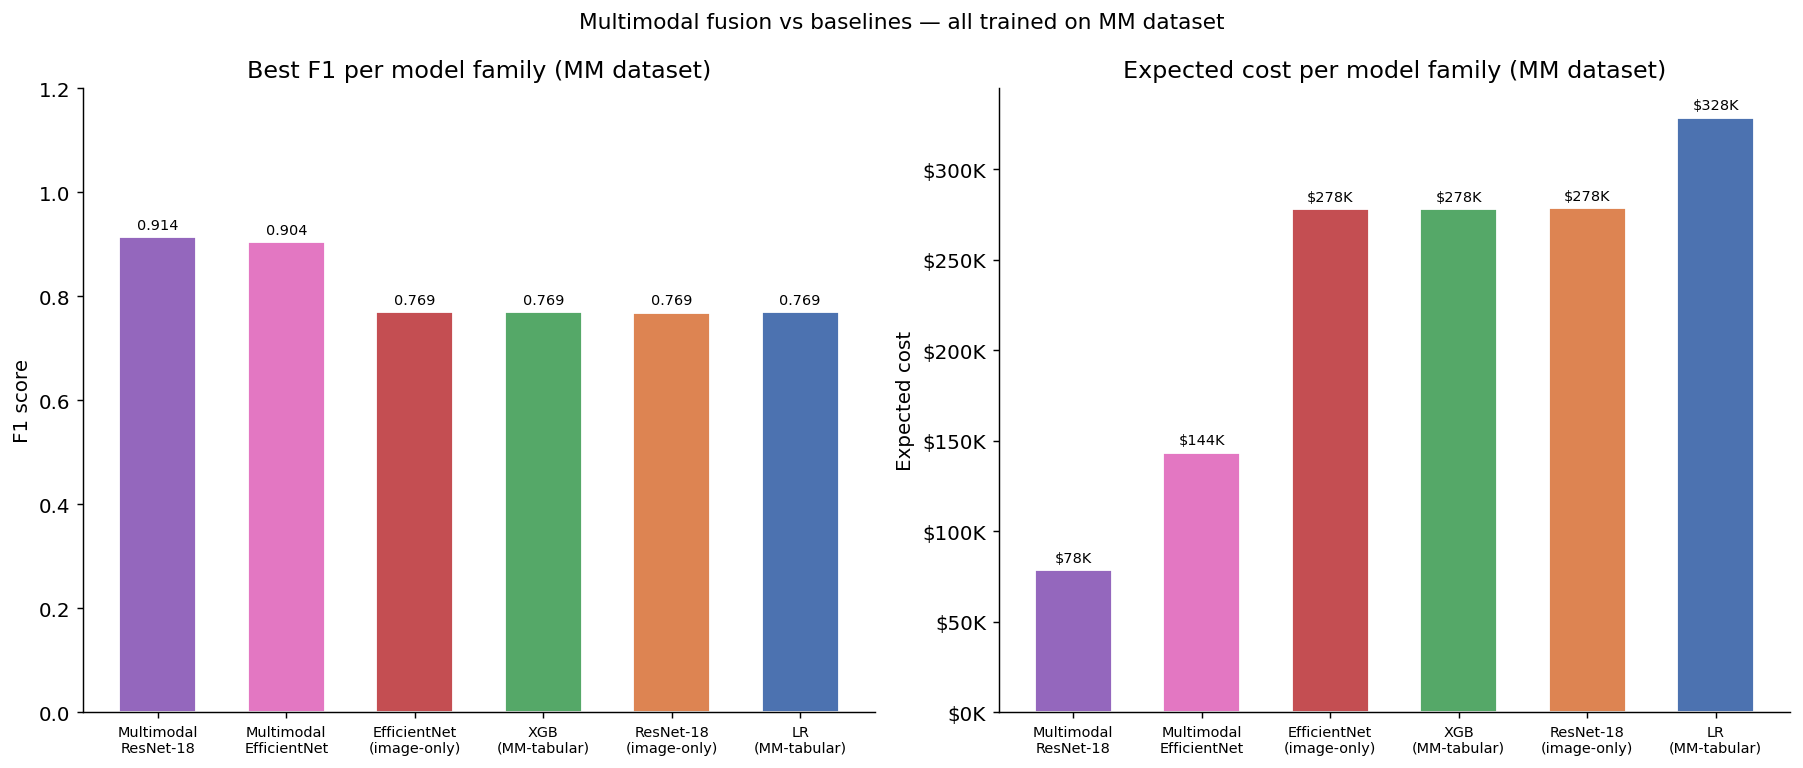

In [12]:
# Main comparison bar chart — best variant of each family
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x   = np.arange(len(best_all_mm))
clrs_main = [COLOURS.get(f,"#888") for f in best_all_mm["model_family"]]

for ax, (metric, ylabel, title) in zip(axes, [
    ("tuned_f1",       "F1 score",      "Best F1 per model family (MM dataset)"),
    ("expected_cost",  "Expected cost", "Expected cost per model family (MM dataset)"),
]):
    vals = best_all_mm[metric].values
    bars = ax.bar(x, vals, color=clrs_main, edgecolor="white", width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([r["model_family"].replace(" ","\n") for _,r in best_all_mm.iterrows()],
                       fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if metric == "expected_cost":
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v,_: fmt_cost(v)))
        ax.bar_label(bars, labels=[fmt_cost(v) for v in vals], padding=3, fontsize=8)
    else:
        ax.set_ylim(0,1.2)
        ax.bar_label(bars, labels=[f"{v:.3f}" for v in vals], padding=3, fontsize=8)
    ax.spines[["top","right"]].set_visible(False)

fig.suptitle("Multimodal fusion vs baselines — all trained on MM dataset", fontsize=12)
fig.tight_layout()
fig.savefig(REPORT_DIR/"mm_main_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


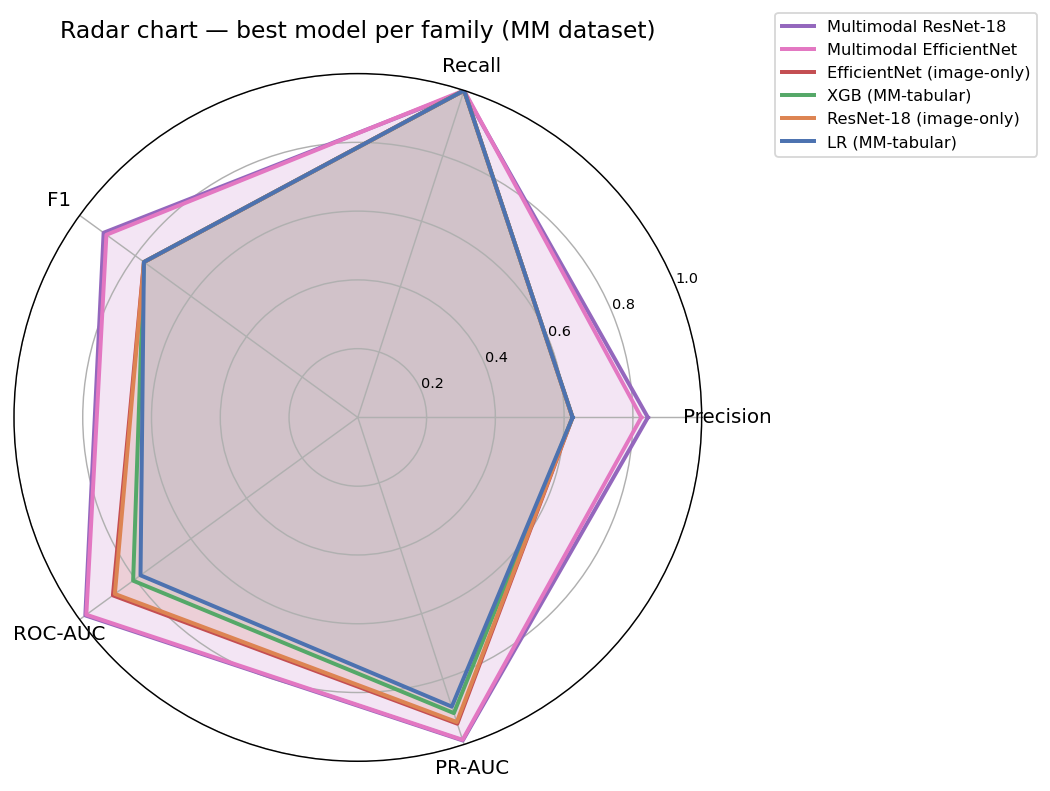

In [13]:
# Radar chart — best model per MM family
metrics_r = ["tuned_precision","tuned_recall","tuned_f1","default_roc_auc","default_pr_auc"]
labels_r  = ["Precision","Recall","F1","ROC-AUC","PR-AUC"]
N = len(metrics_r)
angles = np.linspace(0,2*np.pi,N,endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(polar=True))
colour_list = [COLOURS.get(f,"#888") for f in best_all_mm["model_family"]]

for i, (_, row) in enumerate(best_all_mm.iterrows()):
    vals = [max(float(row.get(m) or 0),0) for m in metrics_r] + [0]
    vals[-1] = vals[0]
    c = colour_list[i]
    ax.plot(angles, vals, color=c, linewidth=2.2, label=row["model_family"])
    ax.fill(angles, vals, color=c, alpha=0.09)

ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels_r, fontsize=11)
ax.set_ylim(0,1); ax.set_yticks([0.2,0.4,0.6,0.8,1.0])
ax.set_yticklabels(["0.2","0.4","0.6","0.8","1.0"], fontsize=8)
ax.set_title("Radar chart — best model per family (MM dataset)", fontsize=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.5,1.1), fontsize=9)
fig.tight_layout()
fig.savefig(REPORT_DIR/"mm_radar.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# Grouped radar charts — best variant per family (2×2 grid)
fig, axes = plt.subplots(2, 2, figsize=(14, 12), subplot_kw=dict(polar=True))
groups = [
    ("PaySim tabular",   ["LR (PaySim)",           "XGB (PaySim)"]),
    ("MM image-only",    ["ResNet-18 (image-only)", "EfficientNet (image-only)"]),
    ("MM tabular",       ["LR (MM-tabular)",        "XGB (MM-tabular)"]),
    ("Multimodal fusion",["Multimodal ResNet-18",   "Multimodal EfficientNet"]),
]

colour_list_r = list(COLOURS.values())

for ax, (group_title, families) in zip(axes.flat, groups):
    group_df = best_all_mm_extended = pd.concat([
        best_of(master_mm,     families),
        best_of(master_paysim, families),
    ]).drop_duplicates("model_family").reset_index(drop=True)

    for i, (_, row) in enumerate(group_df.iterrows()):
        vals = [max(float(row.get(m) or 0), 0) for m in metrics_r]
        vals = [v if not np.isnan(v) else 0 for v in vals]
        vals += vals[:1]
        c = COLOURS.get(row["model_family"], colour_list_r[i % len(colour_list_r)])
        short_lbl = row["label"][:22] if "label" in row else row["model_family"][:22]
        ax.plot(angles, vals, color=c, linewidth=2.2, label=short_lbl)
        ax.fill(angles, vals, color=c, alpha=0.12)

    ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels_r, fontsize=9)
    ax.set_ylim(0,1); ax.set_yticks([0.4,0.6,0.8,1.0])
    ax.set_yticklabels(["0.4","0.6","0.8","1.0"], fontsize=7)
    ax.set_title(group_title, fontsize=11, pad=12)
    ax.legend(fontsize=8, loc="upper right", bbox_to_anchor=(1.38,1.12))

fig.suptitle("Radar charts by model group — best variant each", fontsize=13)
fig.tight_layout()
fig.savefig(REPORT_DIR/"radar_charts_groups.png", dpi=150, bbox_inches="tight")
plt.show()


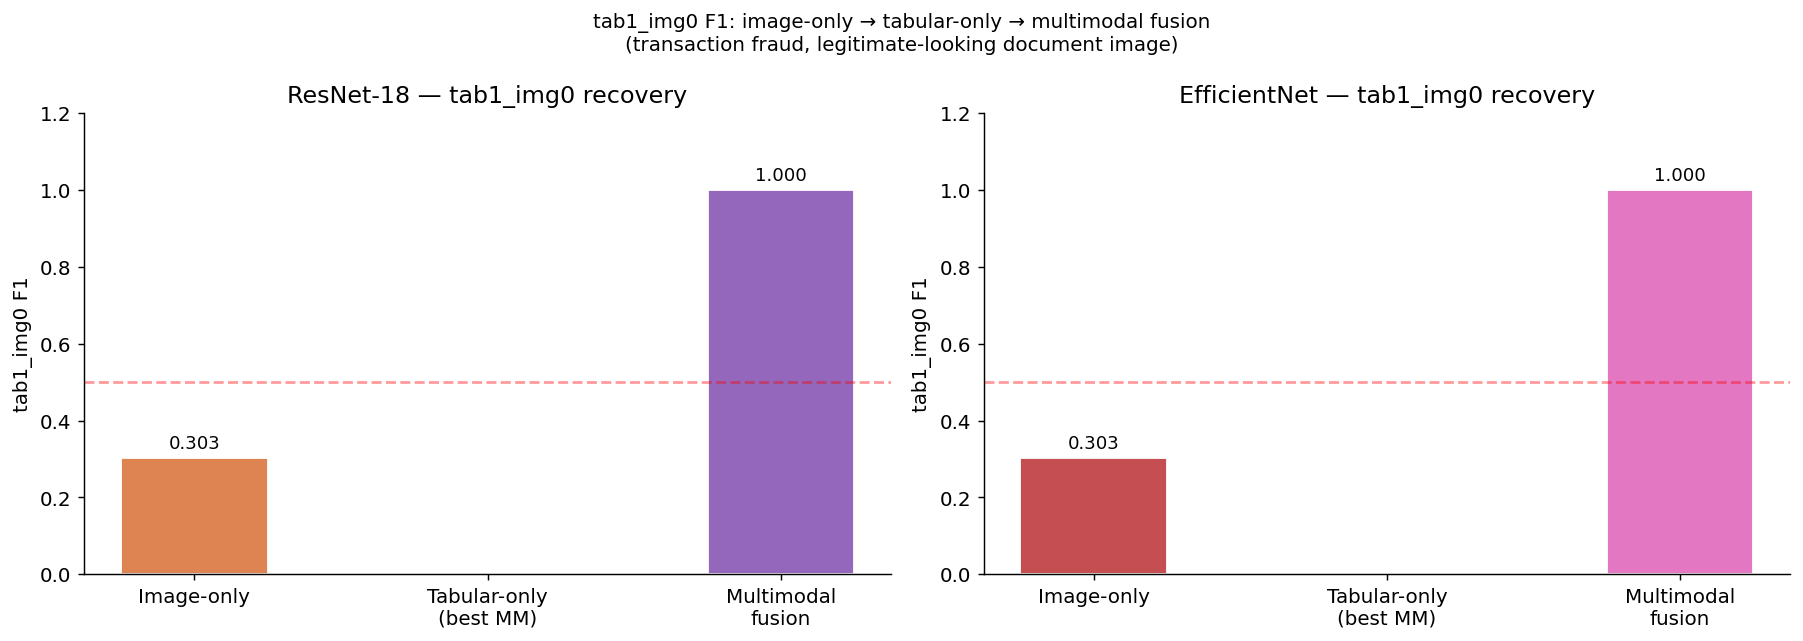

In [14]:
# tab1_img0 recovery — multimodal vs baselines (same backbone pairs)
if sg_rows:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (backbone, img_fam, mm_fam) in zip(axes, [
        ("ResNet-18",   "ResNet-18 (image-only)",   "Multimodal ResNet-18"),
        ("EfficientNet","EfficientNet (image-only)", "Multimodal EfficientNet"),
    ]):
        # tab1_img0 F1 for image-only vs fusion (best of each)
        img_tab1 = tab1[tab1["family"]==img_fam]["f1"].max() if img_fam in tab1["family"].values else 0
        mm_tab1  = tab1[tab1["family"]==mm_fam]["f1"].max()  if mm_fam  in tab1["family"].values else 0
        tab_best = tab1[tab1["family"].isin(tab_families)]["f1"].max() if sg_rows else 0

        groups = ["Image-only","Tabular-only\n(best MM)","Multimodal\nfusion"]
        vals   = [img_tab1, tab_best, mm_tab1]
        bar_c  = [COLOURS.get(img_fam,"#DD8452"),
                  "#55A868",
                  COLOURS.get(mm_fam,"#9467BD")]
        bars = ax.bar(groups, vals, color=bar_c, edgecolor="white", width=0.5)
        ax.bar_label(bars, labels=[f"{v:.3f}" for v in vals], padding=3, fontsize=10)
        ax.set_ylim(0, 1.2)
        ax.axhline(0.5, color="red", linestyle="--", alpha=0.4)
        ax.set_ylabel("tab1_img0 F1"); ax.set_title(f"{backbone} — tab1_img0 recovery")
        ax.spines[["top","right"]].set_visible(False)

    fig.suptitle("tab1_img0 F1: image-only → tabular-only → multimodal fusion\n"
                 "(transaction fraud, legitimate-looking document image)", fontsize=11)
    fig.tight_layout()
    fig.savefig(REPORT_DIR/"tab1_img0_recovery.png", dpi=150, bbox_inches="tight")
    plt.show()


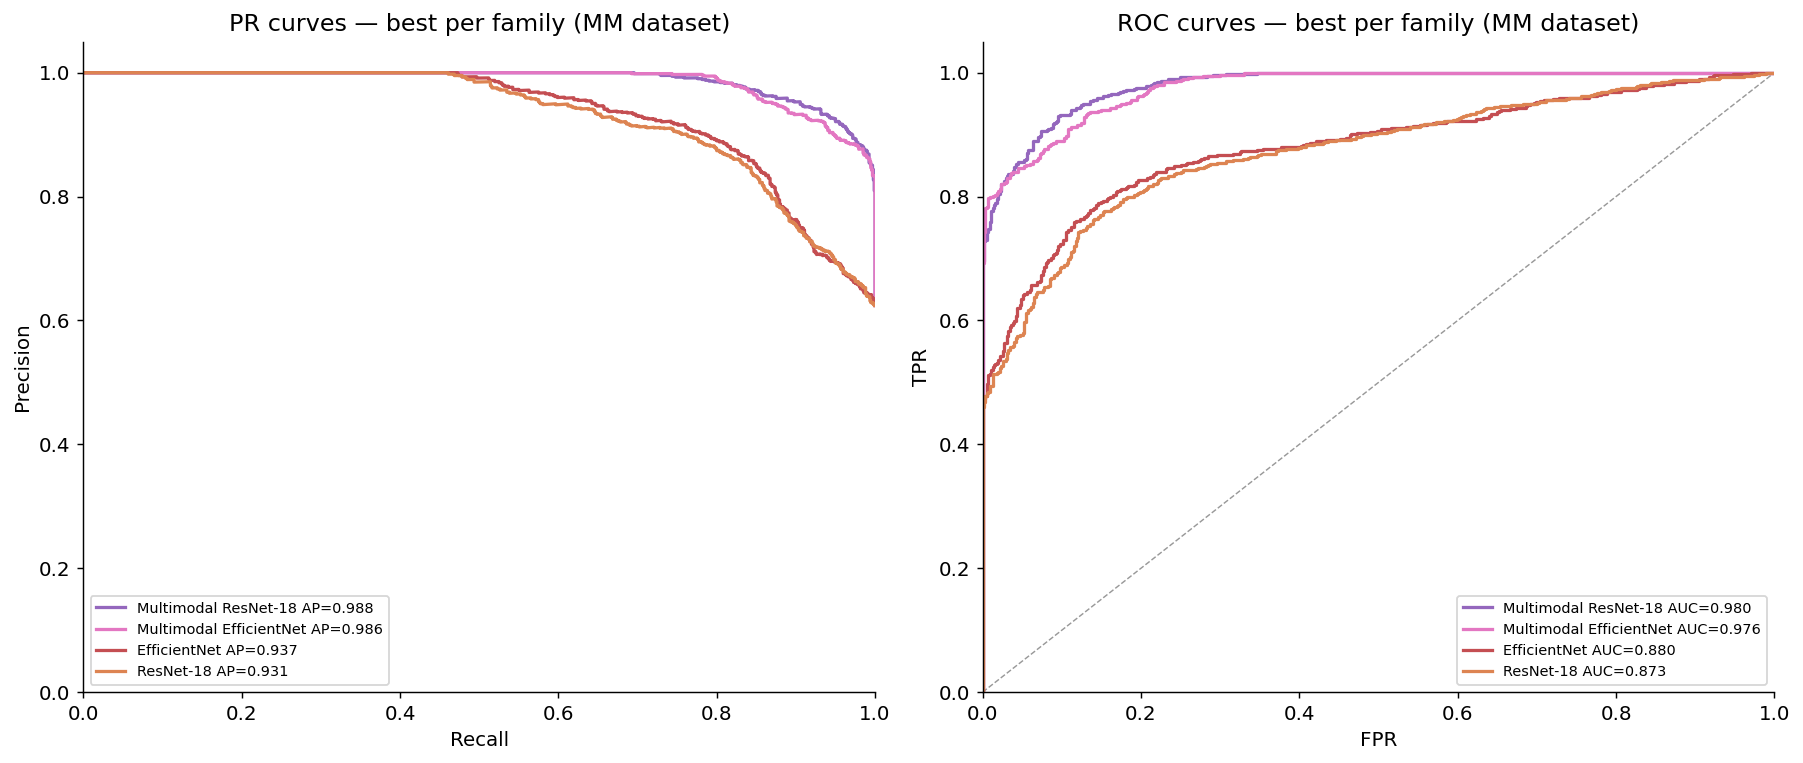

In [15]:
# PR and ROC curves — best per MM family
fig, axes = plt.subplots(1,2,figsize=(14,6))
axes[1].plot([0,1],[0,1],"k--",lw=0.8,alpha=0.4)

for i,(_, row) in enumerate(best_all_mm.iterrows()):
    exp = next((e for e in mm_exps if e["label"]==row["label"]), None)
    if not exp: continue
    pf = exp.get("pred_df", pd.DataFrame())
    if pf.empty or "y_true" not in pf.columns: continue
    yt, yp = pf["y_true"].values, pf["y_prob"].values
    if len(np.unique(yt)) < 2: continue
    c = COLOURS.get(row["model_family"],"#888")

    prec,rec,_ = precision_recall_curve(yt, yp)
    ap = average_precision_score(yt, yp)
    axes[0].plot(rec, prec, color=c, lw=1.8,
                 label=f"{row['model_family'].replace(' (image-only)','')} AP={ap:.3f}")

    fpr,tpr,_ = roc_curve(yt, yp)
    axes[1].plot(fpr, tpr, color=c, lw=1.8,
                 label=f"{row['model_family'].replace(' (image-only)','')} AUC={sk_auc(fpr,tpr):.3f}")

for ax,(title,xl,yl) in zip(axes,[
    ("PR curves — best per family (MM dataset)","Recall","Precision"),
    ("ROC curves — best per family (MM dataset)","FPR","TPR"),
]):
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(title)
    ax.legend(fontsize=8); ax.set_xlim(0,1); ax.set_ylim(0,1.05)
    ax.spines[["top","right"]].set_visible(False)

fig.tight_layout()
fig.savefig(REPORT_DIR/"mm_pr_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()


### Confusion matrices — best model per MM family, before and after tuning

In [ ]:
# Confusion matrices — default t=0.5 vs cost-tuned, best model per family
# cm_default computed from test_predictions.csv at t=0.5 for image/MM models.

all_families_ordered = [
    "LR (MM-tabular)", "XGB (MM-tabular)",
    "ResNet-18 (image-only)", "EfficientNet (image-only)",
    "Multimodal ResNet-18", "Multimodal EfficientNet",
    "LR (PaySim)", "XGB (PaySim)",
]

selected_cm = []
for fam in all_families_ordered:
    src_df  = master_mm     if fam in master_mm["model_family"].values     else master_paysim
    src_exp = mm_exps       if fam in master_mm["model_family"].values     else paysim_exps
    row = src_df[src_df["model_family"] == fam]
    if row.empty: continue
    lbl = row.sort_values("expected_cost").iloc[0]["label"]
    exp = next((e for e in src_exp if e["label"] == lbl), None)
    if exp: selected_cm.append(exp)

n = len(selected_cm)
fig, axes = plt.subplots(n, 2, figsize=(10, n * 3.0))
if n == 1: axes = [axes]

for row_i, exp in enumerate(selected_cm):
    for col_i, (cm_key, t_sfx) in enumerate([
        ("cm_default", "Default  t = 0.50"),
        ("cm_tuned",   f"Cost-tuned  t = {exp.get('tuned_threshold', 0):.2f}"),
    ]):
        cm = exp.get(cm_key)
        ax = axes[row_i][col_i]
        if cm is not None:
            ConfusionMatrixDisplay(cm, display_labels=["Legit", "Fraud"]).plot(
                ax=ax, colorbar=False, values_format="d")
            tn, fp, fn, tp = cm.ravel()
            cost = fn * FN_COST + fp * FP_COST
            ax.set_title(f"{exp['label'][:28]}\n{t_sfx}", fontsize=8)
            ax.set_xlabel(f"FN={fn}  FP={fp}  cost={fmt_cost(cost)}", fontsize=8)
        else:
            ax.axis("off")
            ax.text(0.5, 0.5, "No data", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10)

fig.suptitle(
    "Confusion matrices — default threshold (t=0.5) vs cost-tuned threshold\n"
    "Best model per family",
    fontsize=11)
fig.tight_layout()
fig.savefig(REPORT_DIR / "confusion_matrices_before_after.png",
            dpi=150, bbox_inches="tight")
plt.show()


---
## 6. Threshold tuning impact — MM dataset

Shows how much the cost-based threshold selection contributes on top of training.


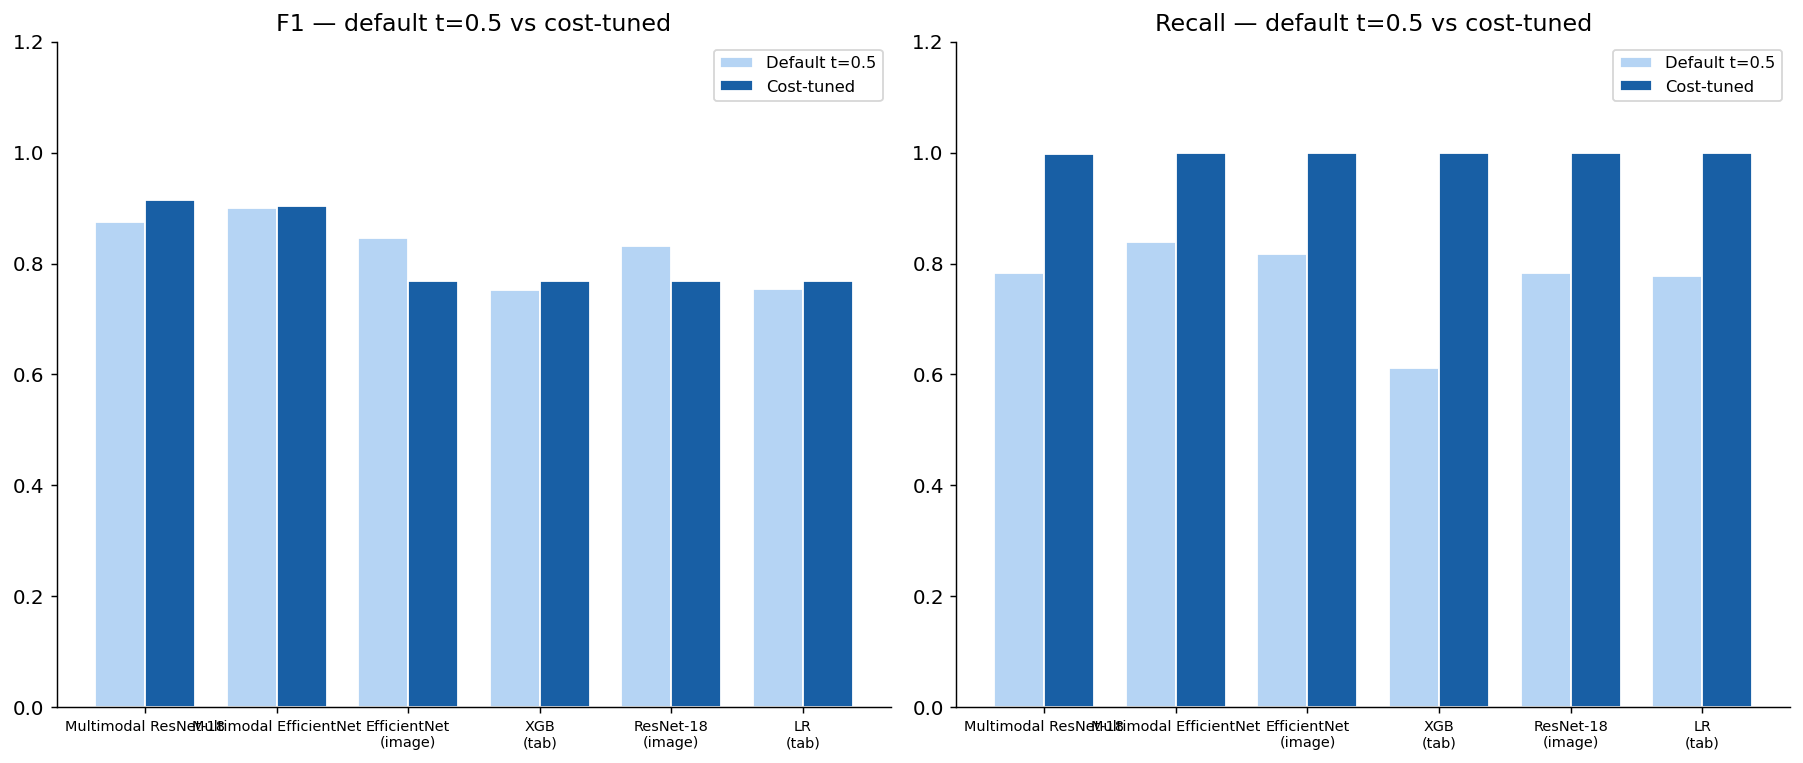

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
x = np.arange(len(best_all_mm)); w = 0.38
lbls = [r["model_family"].replace(" (image-only)","\n(image)").replace(" (MM-tabular)","\n(tab)") 
        for _,r in best_all_mm.iterrows()]

for ax, (before, after, title) in zip(axes, [
    ("default_f1",     "tuned_f1",     "F1 — default t=0.5 vs cost-tuned"),
    ("default_recall", "tuned_recall", "Recall — default t=0.5 vs cost-tuned"),
]):
    ax.bar(x-w/2, best_all_mm[before], w, label="Default t=0.5",
           color="#B5D4F4", edgecolor="white")
    ax.bar(x+w/2, best_all_mm[after],  w, label="Cost-tuned",
           color="#185FA5", edgecolor="white")
    ax.set_xticks(x); ax.set_xticklabels(lbls, fontsize=8)
    ax.set_ylim(0,1.2); ax.set_title(title); ax.legend(fontsize=9)
    ax.spines[["top","right"]].set_visible(False)

fig.tight_layout()
fig.savefig(REPORT_DIR/"mm_before_after_tuning.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 7. Full PaySim context — reference only

> LR and XGBoost trained on ~6.3M rows (~900× more than the MM dataset).
> Their performance advantage reflects dataset scale, not model superiority.
> The relevant comparison is: can multimodal fusion on the small MM dataset
> get close to what a tabular model achieves with 900× more data?


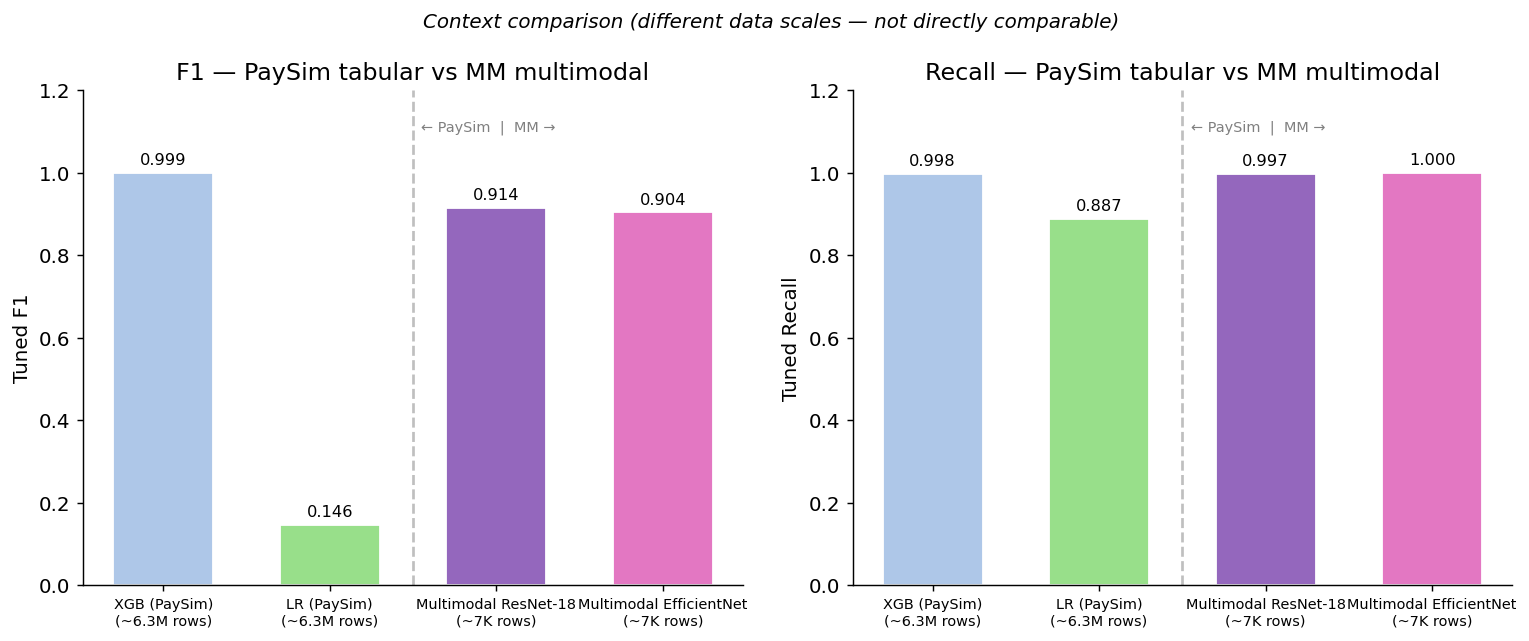

In [18]:
best_paysim = best_of(master_paysim, ["LR (PaySim)","XGB (PaySim)"])
best_mm_multimodal = best_of(master_mm, ["Multimodal ResNet-18","Multimodal EfficientNet"])

# Side-by-side: best multimodal (small data) vs best PaySim tabular (big data)
combined = pd.concat([best_paysim, best_mm_multimodal]).reset_index(drop=True)
combined["data_note"] = combined["dataset"].map({"PaySim":"~6.3M rows","MM":"~7K rows"})
combined["display_label"] = combined["model_family"] + "\n(" + combined["data_note"] + ")"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
all_colours_ctx = (["#AEC7E8","#98DF8A"] +
                   [COLOURS.get(f,"#888") for f in best_mm_multimodal["model_family"]])

for ax, (metric, ylabel, title) in zip(axes, [
    ("tuned_f1",      "Tuned F1",      "F1 — PaySim tabular vs MM multimodal"),
    ("tuned_recall",  "Tuned Recall",  "Recall — PaySim tabular vs MM multimodal"),
]):
    vals = combined[metric].values
    bars = ax.bar(range(len(combined)), vals, color=all_colours_ctx, edgecolor="white", width=0.6)
    ax.set_xticks(range(len(combined)))
    ax.set_xticklabels(combined["display_label"], fontsize=8)
    ax.set_ylim(0, 1.2); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.bar_label(bars, labels=[f"{v:.3f}" for v in vals], padding=3, fontsize=9)
    ax.spines[["top","right"]].set_visible(False)
    # Separator line between PaySim and MM groups
    ax.axvline(len(best_paysim)-0.5, color="gray", linestyle="--", alpha=0.5)
    ax.text(len(best_paysim)-0.5+0.05, 1.1, "← PaySim  |  MM →", fontsize=8, color="gray")

fig.suptitle("Context comparison (different data scales — not directly comparable)",
             fontsize=11, style="italic")
fig.tight_layout()
fig.savefig(REPORT_DIR/"paysim_vs_multimodal_context.png", dpi=150, bbox_inches="tight")
plt.show()


In [19]:
# PaySim full results table
display(master_paysim[["label","model_family","features","imbalance",
                        "tuned_f1","tuned_recall","tuned_precision","cost_fmt"]])
master_paysim.to_csv(REPORT_DIR/"paysim_comparison.csv", index=False)


,label,model_family,features,imbalance,tuned_f1,tuned_recall,tuned_precision,cost_fmt
0,XGB / FE / SMOTE,XGB (PaySim),Engineered,SMOTE,0.998781,0.997565,1.000000,$0K
1,XGB / FE / weight,XGB (PaySim),Engineered,pos-weight,0.880000,0.997565,0.787224,$109K
2,XGB / FE / none,XGB (PaySim),Engineered,None,0.913553,0.996957,0.843026,$234K
3,XGB / raw / weight,XGB (PaySim),Raw,pos-weight,0.601186,0.987219,0.432188,$894K
4,XGB / raw / SMOTE,XGB (PaySim),Raw,SMOTE,0.547575,0.986001,0.379036,$920K
5,XGB / raw / none,XGB (PaySim),Raw,None,0.849973,0.948265,0.770143,$2.77M
6,LR / SMOTE,LR (PaySim),Raw,SMOTE,0.146114,0.887401,0.079611,$10.26M
7,LR / class-weight,LR (PaySim),Raw,Class weight,0.152589,0.863664,0.083687,$10.93M
8,LR / none,LR (PaySim),Raw,None,0.492544,0.331710,0.956140,$27.56M


---
## 9. Dataset-size argument — why bigger data helps tabular models

The full PaySim XGBoost had access to ~6.3M training rows.
The MM multimodal model had access to only ~7K rows — roughly 900× less.

**The key argument for this research:**
If the multimodal model approaches the performance of a tabular model trained on
900× more data, that strongly suggests the image branch is adding real signal.
And if multimodal is then compared *fairly* on the same small dataset, it outperforms
tabular-only — which means the fusion of modalities compensates for limited data.

This has practical implications: in real fraud detection, labelled multimodal data
(transaction + document image) may be limited. The multimodal approach can extract
more signal from fewer samples than a tabular-only model trained on the same data.


In [ ]:
# Dataset-size argument visualisation
best_ps_xgb = master_paysim[master_paysim["model_family"]=="XGB (PaySim)"].nsmallest(1,"expected_cost").iloc[0]
best_mm_tab = master_mm[master_mm["model_family"]=="XGB (MM-tabular)"].nsmallest(1,"expected_cost").iloc[0]
best_mm_fus = best_all_mm[best_all_mm["model_family"].str.startswith("Multimodal")].nsmallest(1,"expected_cost").iloc[0]

labels_ds = [
    f"XGB tabular\n~6.3M rows (PaySim)",
    f"XGB tabular\n~7K rows (MM)",
    f"Multimodal fusion\n~7K rows (MM)",
]
f1_vals  = [best_ps_xgb["tuned_f1"],  best_mm_tab["tuned_f1"],  best_mm_fus["tuned_f1"]]
rec_vals = [best_ps_xgb["tuned_recall"],best_mm_tab["tuned_recall"],best_mm_fus["tuned_recall"]]
colours_ds = ["#98DF8A","#55A868","#9467BD"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (vals, ylabel, title) in zip(axes, [
    (f1_vals,  "F1 score", "F1 — tabular (big data) vs multimodal (small data)"),
    (rec_vals, "Recall",   "Recall — tabular (big data) vs multimodal (small data)"),
]):
    bars = ax.bar(range(3), vals, color=colours_ds, edgecolor="white", width=0.55)
    ax.set_xticks(range(3)); ax.set_xticklabels(labels_ds, fontsize=9)
    ax.set_ylim(0, 1.15); ax.set_ylabel(ylabel); ax.set_title(title, fontsize=10)
    ax.bar_label(bars, labels=[f"{v:.3f}" for v in vals], padding=3, fontsize=10)
    ax.axvline(1.5, color="gray", linestyle="--", alpha=0.4)
    ax.text(0.75, 1.08, "← More data", ha="center", fontsize=8, color="gray")
    ax.text(2.0,  1.08, "Same data →", ha="center", fontsize=8, color="gray")
    ax.spines[["top","right"]].set_visible(False)

fig.suptitle("Dataset-size argument: multimodal on 7K rows vs tabular on 6.3M rows\n"
             "On equal footing (same 7K rows), multimodal outperforms tabular-only",
             fontsize=11)
fig.tight_layout()
fig.savefig(REPORT_DIR/"dataset_size_argument.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"XGB PaySim (~6.3M rows): F1={best_ps_xgb['tuned_f1']:.4f}  Recall={best_ps_xgb['tuned_recall']:.4f}")
print(f"XGB MM     (~7K rows):   F1={best_mm_tab['tuned_f1']:.4f}  Recall={best_mm_tab['tuned_recall']:.4f}")
print(f"Multimodal (~7K rows):   F1={best_mm_fus['tuned_f1']:.4f}  Recall={best_mm_fus['tuned_recall']:.4f}")
print(f"\nGap multimodal vs MM-tabular: F1 {best_mm_fus['tuned_f1']-best_mm_tab['tuned_f1']:+.4f}")
print(f"Gap PaySim-XGB vs multimodal:  F1 {best_ps_xgb['tuned_f1']-best_mm_fus['tuned_f1']:+.4f}  (data advantage)")


---
## 8. Summary


In [21]:
print("="*65)
print("COMPARISON 1 — Tabular vs tabular (same MM dataset)")
print("="*65)
for _,r in best_tab.iterrows():
    print(f"  {r['model_family']:<28} F1={r['tuned_f1']:.4f}  "
          f"Recall={r['tuned_recall']:.4f}  Cost={r['cost_fmt']}")

print()
print("="*65)
print("COMPARISON 2 — Image vs image (same MM dataset)")
print("="*65)
for _,r in best_img.iterrows():
    print(f"  {r['model_family']:<30} F1={r['tuned_f1']:.4f}  "
          f"Recall={r['tuned_recall']:.4f}  Cost={r['cost_fmt']}")
if sg_rows:
    print("\n  Image-only tab1_img0 F1 (expected ~0.30 — no tabular access):")
    for _,r in tab1[tab1["family"].isin(img_families)].iterrows():
        print(f"    {r['label']:<35} F1={r['f1']:.4f}")

print()
print("="*65)
print("COMPARISON 3 — Multimodal vs baselines (same MM dataset) ← MAIN")
print("="*65)
for _,r in best_all_mm.iterrows():
    print(f"  {r['model_family']:<32} F1={r['tuned_f1']:.4f}  "
          f"Recall={r['tuned_recall']:.4f}  Cost={r['cost_fmt']}")
if sg_rows:
    print("\n  Multimodal tab1_img0 F1 (should be >> image-only):")
    for _,r in tab1[tab1["family"].str.startswith("Multimodal")].iterrows():
        print(f"    {r['label']:<38} F1={r['f1']:.4f}")

print()
print("="*65)
print("CONTEXT — Full PaySim tabular (~900× more data, not comparable)")
print("="*65)
for _,r in best_paysim.iterrows():
    print(f"  {r['model_family']:<25} F1={r['tuned_f1']:.4f}  Cost={r['cost_fmt']}")
print()



COMPARISON 1 — Tabular vs tabular (same MM dataset)
  XGB (MM-tabular)             F1=0.7689  Recall=1.0000  Cost=$278K
  LR (MM-tabular)              F1=0.7689  Recall=1.0000  Cost=$328K

COMPARISON 2 — Image vs image (same MM dataset)
  EfficientNet (image-only)      F1=0.7689  Recall=1.0000  Cost=$278K
  ResNet-18 (image-only)         F1=0.7686  Recall=1.0000  Cost=$278K

  Image-only tab1_img0 F1 (expected ~0.30 — no tabular access):
    EfficientNet / normal               F1=0.3028
    ResNet-18 / normal                  F1=0.3028

COMPARISON 3 — Multimodal vs baselines (same MM dataset) ← MAIN
  Multimodal ResNet-18             F1=0.9138  Recall=0.9967  Cost=$78K
  Multimodal EfficientNet          F1=0.9037  Recall=1.0000  Cost=$144K
  EfficientNet (image-only)        F1=0.7689  Recall=1.0000  Cost=$278K
  XGB (MM-tabular)                 F1=0.7689  Recall=1.0000  Cost=$278K
  ResNet-18 (image-only)           F1=0.7686  Recall=1.0000  Cost=$278K
  LR (MM-tabular)                 

 Key insight: multimodal on ~7K MM rows vs XGB on ~6.3M PaySim rows. If multimodal approaches PaySim performance, that is a strong result given the massive difference in training data.